In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import re
import missingno as mno

warnings.filterwarnings("ignore")

%matplotlib inline

## Reading the dataset

In [2]:
df=pd.read_csv("C:/Users/prath/Downloads/Churn Prediction/Data/data.csv")

## Exploring the data

In [3]:
rows=df.shape[0]
columns=df.shape[1]
print(f"Number of rows are {rows} and columns are {columns} in dataset")

Number of rows are 50000 and columns are 23 in dataset


In [4]:
print('Basic Descriptives of dataset')
df.describe()

Basic Descriptives of dataset


,annual_revenue_usd,contract_value_usd,tenure_months,product_usage_hours_3m,product_usage_hours_12m,login_frequency_30d,active_users,licensed_users,analyst_calls_6m,support_tickets_6m,support_escalations_6m,avg_resolution_time_hrs,nps_score,survey_response_count_12m,churn_flag
count,4.329300e+04,37265.000000,38426.000000,41870.000000,45525.000000,47172.000000,43536.000000,34551.000000,40008.000000,43422.000000,38485.000000,36498.000000,44607.000000,45071.000000,50000.000000
mean,1.780618e+05,89626.491643,29.945878,119.757052,520.213156,9.970846,5.990835,37.047553,1.508823,3.513565,0.598597,49.289553,-0.540857,1.189900,0.019640
std,4.209833e+05,45142.215930,29.678752,54.996010,180.040394,10.034615,2.459108,35.207416,1.229373,1.876507,0.774340,27.571193,58.127582,1.088492,0.138761
min,1.405019e+02,-101311.360200,0.000814,-109.987458,-182.053525,0.000032,0.000000,5.000000,0.000000,0.000000,0.000000,0.000732,-100.000000,0.000000,0.000000
25%,2.607467e+04,59516.694200,8.831021,82.676742,398.209222,2.883892,4.000000,10.000000,1.000000,2.000000,0.000000,28.082918,-51.000000,0.000000,0.000000
50%,6.636826e+04,89420.840080,20.906898,120.113561,520.095418,6.905612,6.000000,20.000000,1.000000,3.000000,0.000000,47.938245,-1.000000,1.000000,0.000000
75%,1.714133e+05,119800.787600,41.380318,156.962595,642.713605,13.689288,8.000000,50.000000,2.000000,5.000000,1.000000,68.375470,49.000000,2.000000,0.000000
max,2.459942e+07,264519.759500,349.137883,336.146419,1216.458645,104.641769,19.000000,100.000000,10.000000,13.000000,6.000000,170.639284,100.000000,8.000000,1.000000


####
* Median NPS score is -1 i.e. 50% of the accounts are not promoting Gartner to others. Maybe these accounts are not getting enough value from benchmarking products

* Median Login frequency for past 30 days is 6. Not many accounts have login in past one month

* Median Product usage hours in past 3 months is 120. This means a median client is using the product for 10 hours/week which is reasonable engagement(reading product landing pages,reviewing benchmark results,downloading collaterals attached on landing pages)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   client_id                  37285 non-null  object 
 1   industry                   43501 non-null  object 
 2   sub_industry               34321 non-null  object 
 3   region                     42481 non-null  object 
 4   company_size               39957 non-null  object 
 5   annual_revenue_usd         43293 non-null  float64
 6   contract_value_usd         37265 non-null  float64
 7   contract_length_months     39007 non-null  object 
 8   tenure_months              38426 non-null  float64
 9   product_usage_hours_3m     41870 non-null  float64
 10  product_usage_hours_12m    45525 non-null  float64
 11  login_frequency_30d        47172 non-null  float64
 12  active_users               43536 non-null  float64
 13  licensed_users             34551 non-null  flo

In [6]:
numerical_features=[feature for feature in df.columns if df[feature].dtype !="O"]
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O']

print(f"There are {len(numerical_features)} numerical features and they are : {numerical_features}")
print(f"There are {len(categorical_features)} categorical features and they are : {categorical_features}")

There are 15 numerical features and they are : ['annual_revenue_usd', 'contract_value_usd', 'tenure_months', 'product_usage_hours_3m', 'product_usage_hours_12m', 'login_frequency_30d', 'active_users', 'licensed_users', 'analyst_calls_6m', 'support_tickets_6m', 'support_escalations_6m', 'avg_resolution_time_hrs', 'nps_score', 'survey_response_count_12m', 'churn_flag']
There are 8 categorical features and they are : ['client_id', 'industry', 'sub_industry', 'region', 'company_size', 'contract_length_months', 'discount_percent', 'account_notes']


## Data Cleaning/Data Pre-processing

###
Checking duplicates

In [7]:
duplicates=df.duplicated().sum()
print(f'Number of duplicates in the dataset : {duplicates}')

Number of duplicates in the dataset : 0


###
Dropping client_id since it is not important for analysis

In [8]:
df=df.drop(columns=['client_id'],axis=1)

In [9]:
df.columns

Index(['industry', 'sub_industry', 'region', 'company_size',
       'annual_revenue_usd', 'contract_value_usd', 'contract_length_months',
       'tenure_months', 'product_usage_hours_3m', 'product_usage_hours_12m',
       'login_frequency_30d', 'active_users', 'licensed_users',
       'analyst_calls_6m', 'support_tickets_6m', 'support_escalations_6m',
       'avg_resolution_time_hrs', 'nps_score', 'survey_response_count_12m',
       'discount_percent', 'account_notes', 'churn_flag'],
      dtype='object')

####
Standardizing the values in the columns. Replacing special characters and maintaining consistency.

In [10]:
def clean_industry(industry):
    
    if pd.isna(industry):
        return None
    industry=industry.lower()
    industry=re.sub(r"[^a-z\s]","a",industry)
    industry=industry.strip()

    mapping={
        "finanace":'Finance',
        'finance':'Finance',
        "retail":"Retail",
        'Heathcare':"Healthcare",
        'heathcare':"Healthcare",
        'manufacturing':"Manufacturing",
        'manufacturin':"Manufacturing",
        'TECH':"Technology",
        'technology':"Technology",
        'tech':"Technology",
        'saas':"Saas",
        'energy':"Energy"
    }
    return mapping.get(industry,industry.title())


def clean_region(region):
    
    if pd.isna(region):
        return None
    region=region.lower()
    region=re.sub(r"[^a-z\s]","a",region)
    region=region.strip()

    mapping={
        "north america":"North America",
        'n. america':"North America",
        'north americ':"North America",
        "na america":"North America",
        'latam':"Latam",
        'europe':"Europe",
        'middle east':"Middle East",
        'apac':"Apac"
    }
    return mapping.get(region,region.title())

def clean_sub_industry(sub_industry):
    if pd.isna(sub_industry):
        return None
    sub_industry=sub_industry.lower()
    sub_industry=re.sub(r'[^a-z\s]',"a",sub_industry)
    sub_industry=sub_industry.strip()

    mapping_sub_industry={
    'data':"Data",
    "ai":"AI",
    "cloud":"Cloud",
    "e-commerce":"E-commerce",
    "eacommerce":"E-commerce",
    "payments":"Payments",
    "cybersecurity":"Cybersecurity",
    'infra':"Infra"
    }
    return mapping_sub_industry.get(sub_industry,sub_industry.title())

def clean_contract_length_months(contract_length_months):
    if pd.isna(contract_length_months):
        return None
    mapping_month={
        "36 mnth":'36',
        "12 months":'12'
    }
    return mapping_month.get(contract_length_months,contract_length_months.title())

def clean_company_size(x):
    if pd.isna(x):
        return np.nan
    x=str(x).lower().strip()
    if 'k' in x:
        return int(float(x.replace('k',''))*1000)
    if '+' in x:
        return int(x.replace('+',''))
    return int(x)

In [11]:
df['industry']=df['industry'].apply(clean_industry)
df['region']=df['region'].apply(clean_region)
df['sub_industry']=df['sub_industry'].apply(clean_sub_industry)
df['contract_length_months']=df['contract_length_months'].apply(clean_contract_length_months)
df['company_size']=df['company_size'].apply(clean_company_size)

#### 
Renaming columns of the dataset to enhance readability

In [12]:
df.columns=df.columns.str.replace('_','')
new_column_names=['Industry', 'Sub Industry', 'Region', 'Company size',
       'Annual revenue(USD)', 'Contract value(USD)', 'Contract length(m)',
       'Tenure(m)', 'Product usage hours(3m)', 'Product usage hours(12m)', 'Login frequency(30d)',
       'Active users', 'Licensed users', 'Analyst calls(6m)', 'Support tickets(6m)',
       'Support escalations(6m)', 'Avg resolution time(hrs)', 'Nps score',
       'Survey response count(12m)', 'Discount', 'Account notes',
       'Churn flag']
df=df.set_axis(new_column_names,axis=1)

#### 
Since max of Tenure column is 350 therefore it is stored as months. We will convert tenure into days for better intutition

In [13]:
df['Tenure(d)']=round(df['Tenure(m)']*30,0)
df=df.drop(columns=['Tenure(m)'],axis=1)

####
Converting discount column to float and standardizing the values for better intuition

In [14]:
df['Discount']=df['Discount'].str.replace('%','',regex=True).astype(float)
df['Discount']=df['Discount']/100

#### 
Roudning off the values to 2 decimal places for better readability

In [15]:
cols_round_off=[
    'Annual revenue(USD)',
    'Contract value(USD)',
    'Product usage hours(3m)', 
    'Product usage hours(12m)',
    'Login frequency(30d)',
    'Avg resolution time(hrs)'
]
for col in cols_round_off:
    df[col]=pd.to_numeric(df[col],errors='coerce')

df[cols_round_off]=df[cols_round_off].round(2)

##### 
Challenge: 

Facing issue in changing data types of few columns. Upon investigating noticed that "int" dtype does not support NaN values hence it cannot convert a column that contains such values. After researching got to know that there is a nullable pandas integer dtype that is "Int64" specifically designed to handle integer values along with missing data.

Learning: 

Helped understanding the importance of handling missing values during type conversions. Would prefer using nullable dtypes or safe conversions during preprocessing to make pipelines more robust and avoid runtime errors.

In [16]:
df['Contract length(m)']=df['Contract length(m)'].astype("Int64")
df['Active users']=df['Active users'].astype('Int64')
df['Licensed users']=df['Licensed users'].astype("Int64")
df['Analyst calls(6m)']=df['Analyst calls(6m)'].astype("Int64")
df['Support escalations(6m)']=df['Support escalations(6m)'].astype("Int64")
df['Support tickets(6m)']=df['Support tickets(6m)'].astype("Int64")
df['Nps score']=df['Nps score'].astype("Int64")
df['Survey response count(12m)']=df['Survey response count(12m)'].astype("Int64")
df['Tenure(d)']=df['Tenure(d)'].astype("Int64")
df['Company size']=df['Company size'].astype("Int64")
df['Churn flag']=df['Churn flag'].astype('object')

## EDA(Exploratory Data Analysis)

#### 
What we have and why does it matter

* Contract signals - Contract value, Contract length → price sensitivity & commitment level
* Engagement signals - Product usage hours (3m & 12m), Login frequency, Active vs Licensed users → are they actually using what they pay for?
* Health signals - NPS score, Survey response count → voice of customer
* Risk signals - Support tickets, Support escalations, Avg resolution time → friction & frustration
* Relationship signals - Analyst calls, Discount, Tenure → stickiness & dependency
* Firmographic signals - Industry, Sub Industry, Region, Company size, Annual revenue → segmentation

#### Univariate Analysis

In [17]:
numerical_features=[feature for feature in df.columns if df[feature].dtype !="O"]
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O']

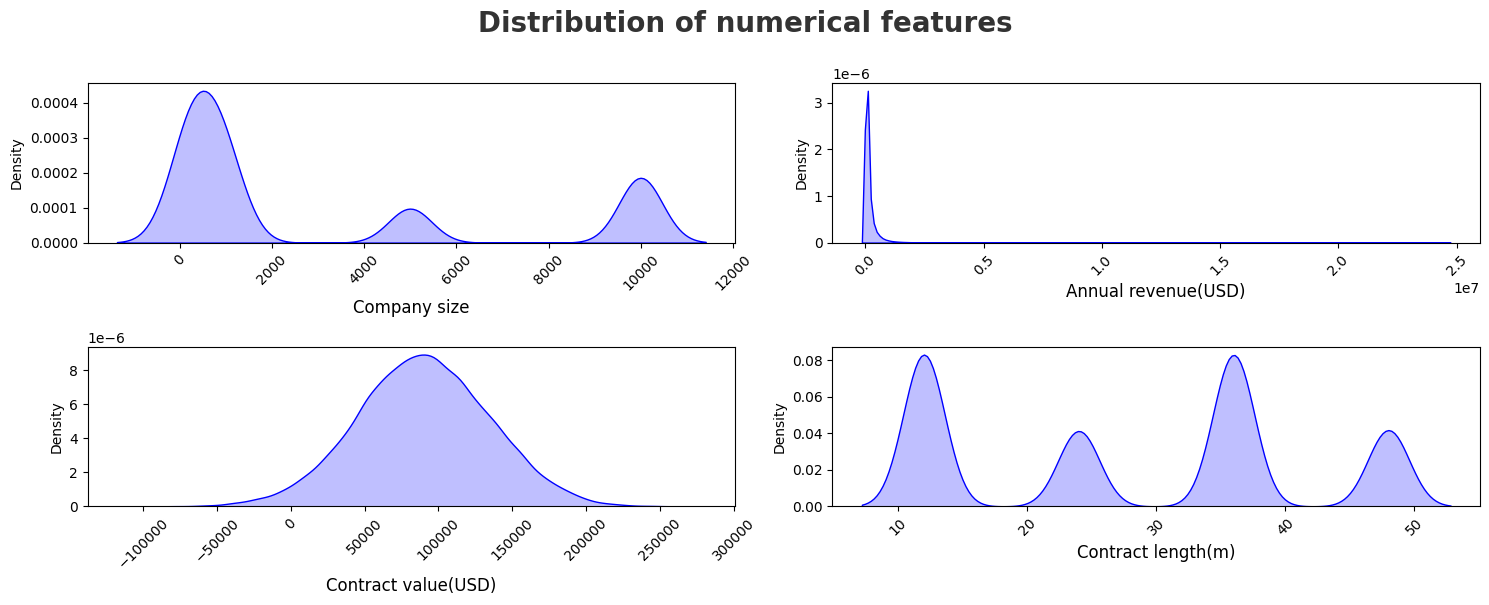

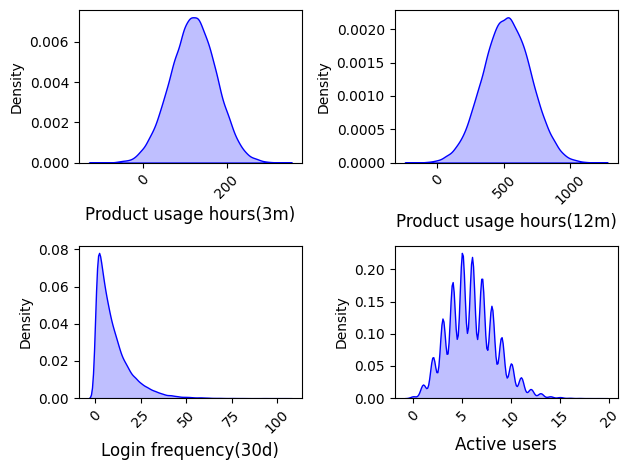

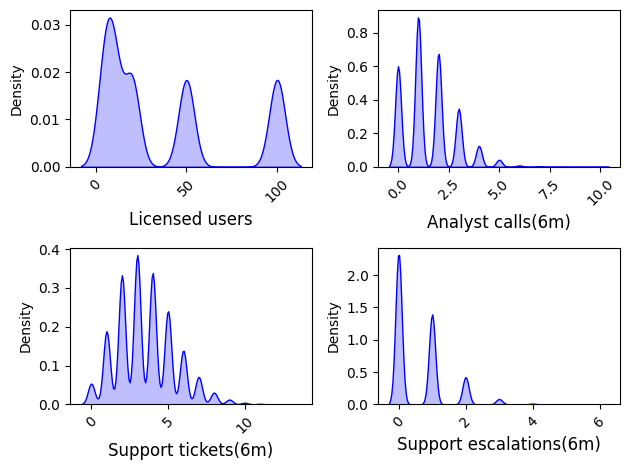

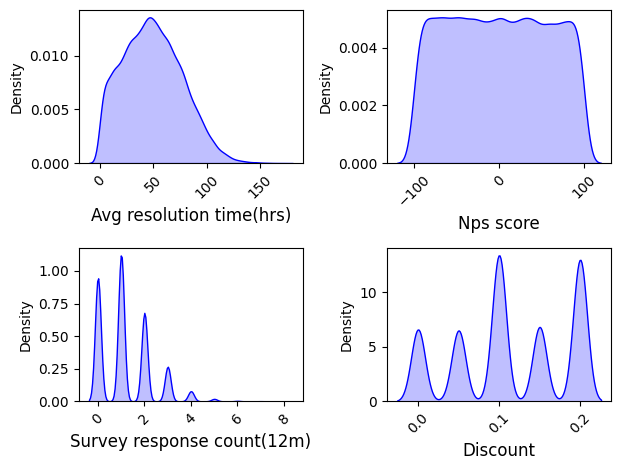

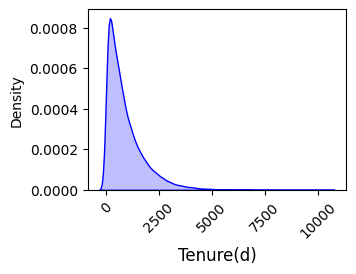

In [18]:
## Numerical features
plt.figure(figsize=(15,6))
plt.suptitle("Distribution of numerical features",fontsize=20,fontweight='bold',alpha=0.8,y=1.)
batch_size=4
for i in range(0,len(numerical_features),batch_size):
    subset=numerical_features[i:i+batch_size]
    for i,col in enumerate(subset):
        plt.subplot(2,2,i+1)
        sns.kdeplot(x=df[col],fill=True,color='blue')
        plt.xlabel(col,fontsize=12)
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

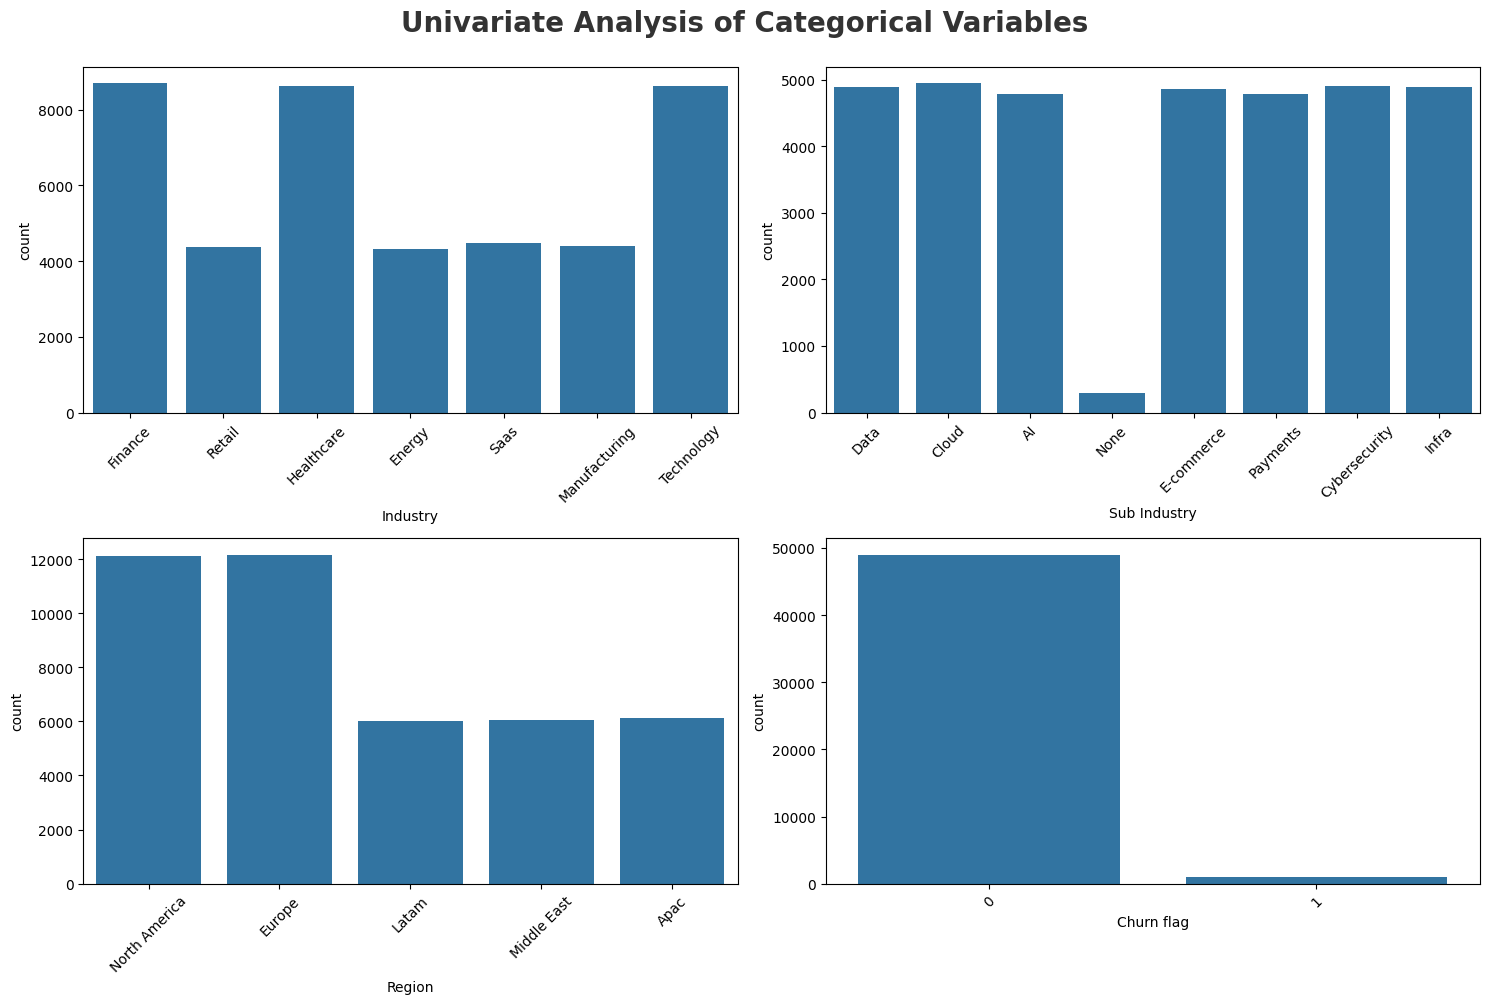

In [19]:
categories=['Industry','Sub Industry','Region','Churn flag']
fig,axes=plt.subplots(2,2,figsize=(15,10))
plt.suptitle('Univariate Analysis of Categorical Variables',fontsize=20,fontweight='bold',alpha=0.8,y=1.)
axes=axes.flatten()
for i,col in enumerate(categories):
    sns.countplot(data=df,x=col,ax=axes[i])
    # axes[i].set_title(col)
    axes[i].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

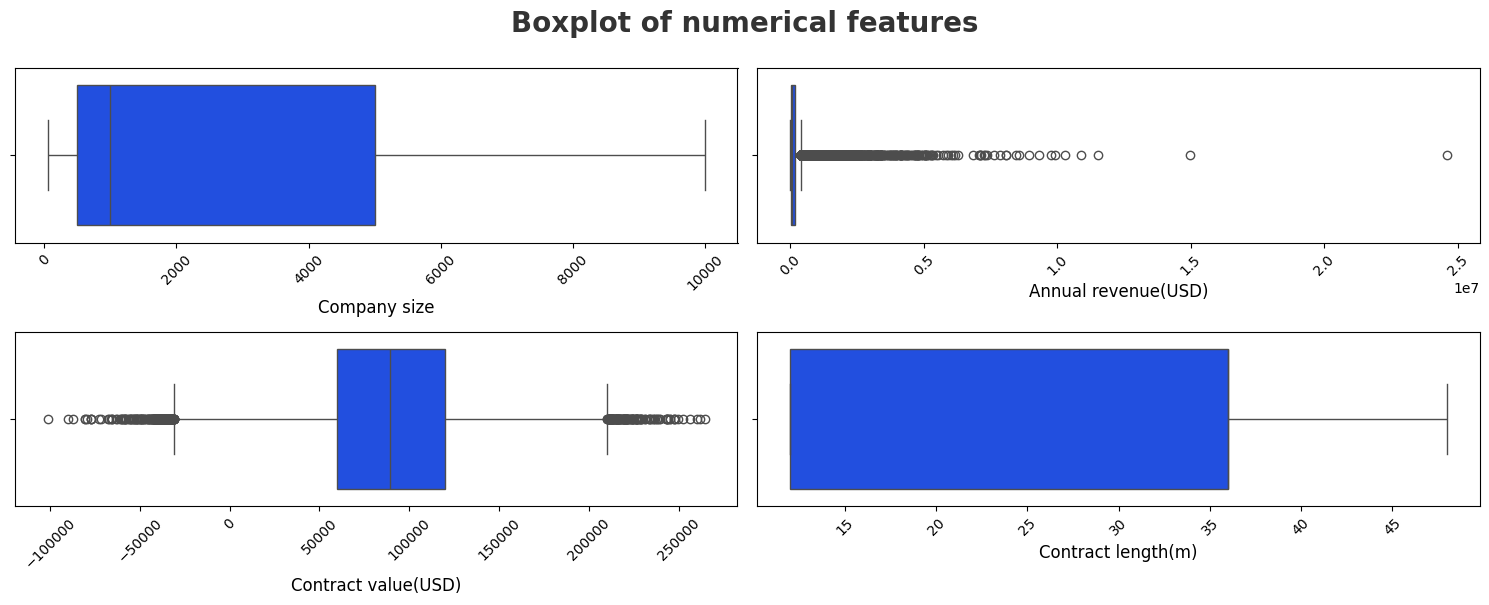

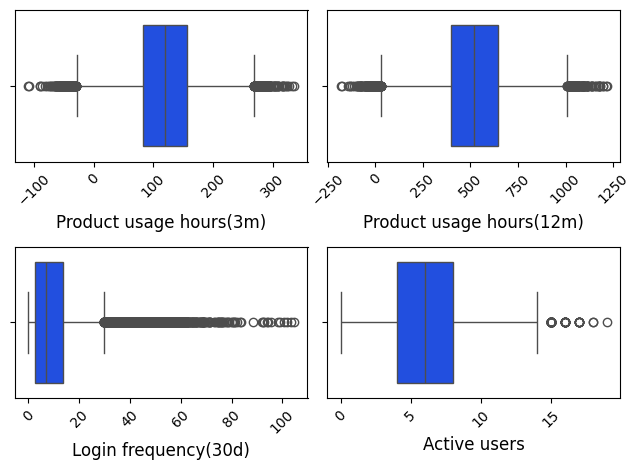

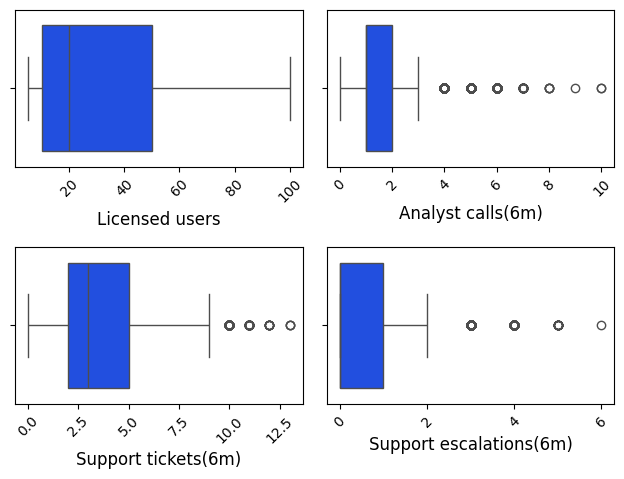

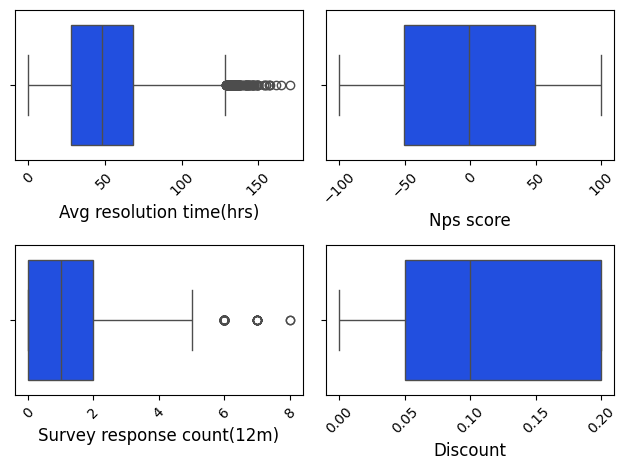

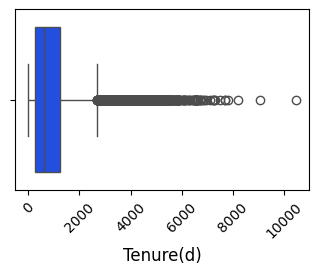

In [20]:
plt.figure(figsize=(15,6))
plt.suptitle("Boxplot of numerical features",fontsize=20,fontweight='bold',alpha=0.8,y=1.)
batch_size=4
for i in range(0,len(numerical_features),batch_size):
    subset=numerical_features[i:i+batch_size]
    for i,col in enumerate(subset):
        plt.subplot(2,2,i+1)
        sns.boxplot(x=df[col],palette='bright')
        plt.xlabel(col,fontsize=12)
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Missing Values Analysis

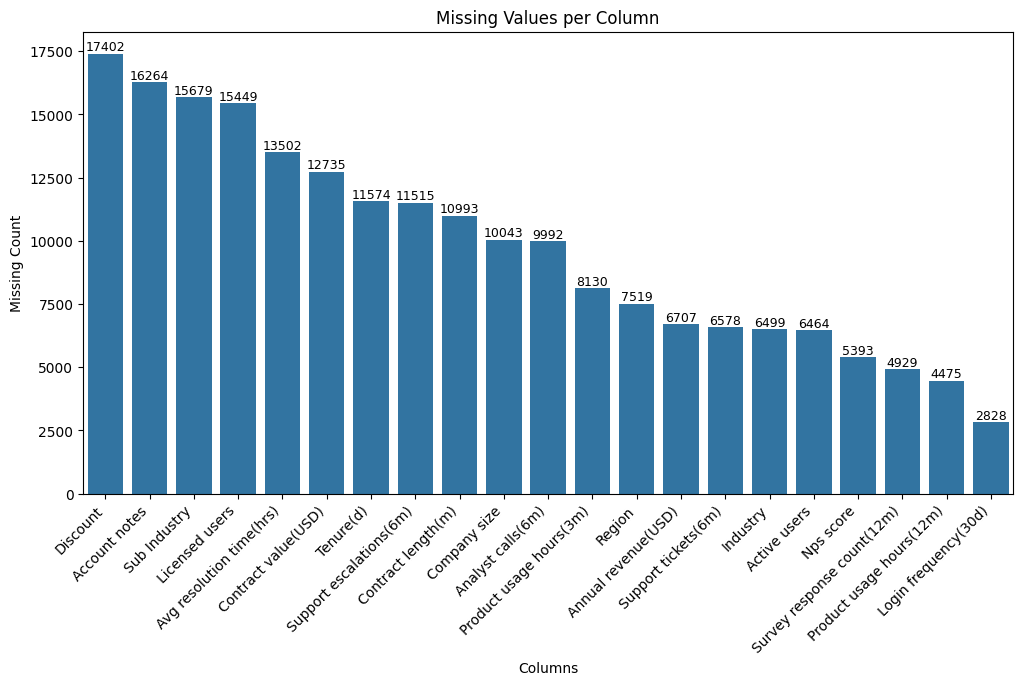

In [43]:
missing_counts = df.isnull().sum().reset_index()
missing_counts.columns = ['column', 'missing_count']
missing_counts = missing_counts[missing_counts['missing_count'] > 0] \
                                   .sort_values(by='missing_count', ascending=False)

plt.figure(figsize=(12, 6))

ax=sns.barplot(data=missing_counts, x='column', y='missing_count')

plt.xticks(rotation=45,ha='right')
for p in ax.patches:
    height=p.get_height()
    if height>0:
        ax.text(
            p.get_x()+p.get_width()/2,
            height,
            int(height),
            ha='center',
            va='bottom',
            fontsize=9
        )
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.show()

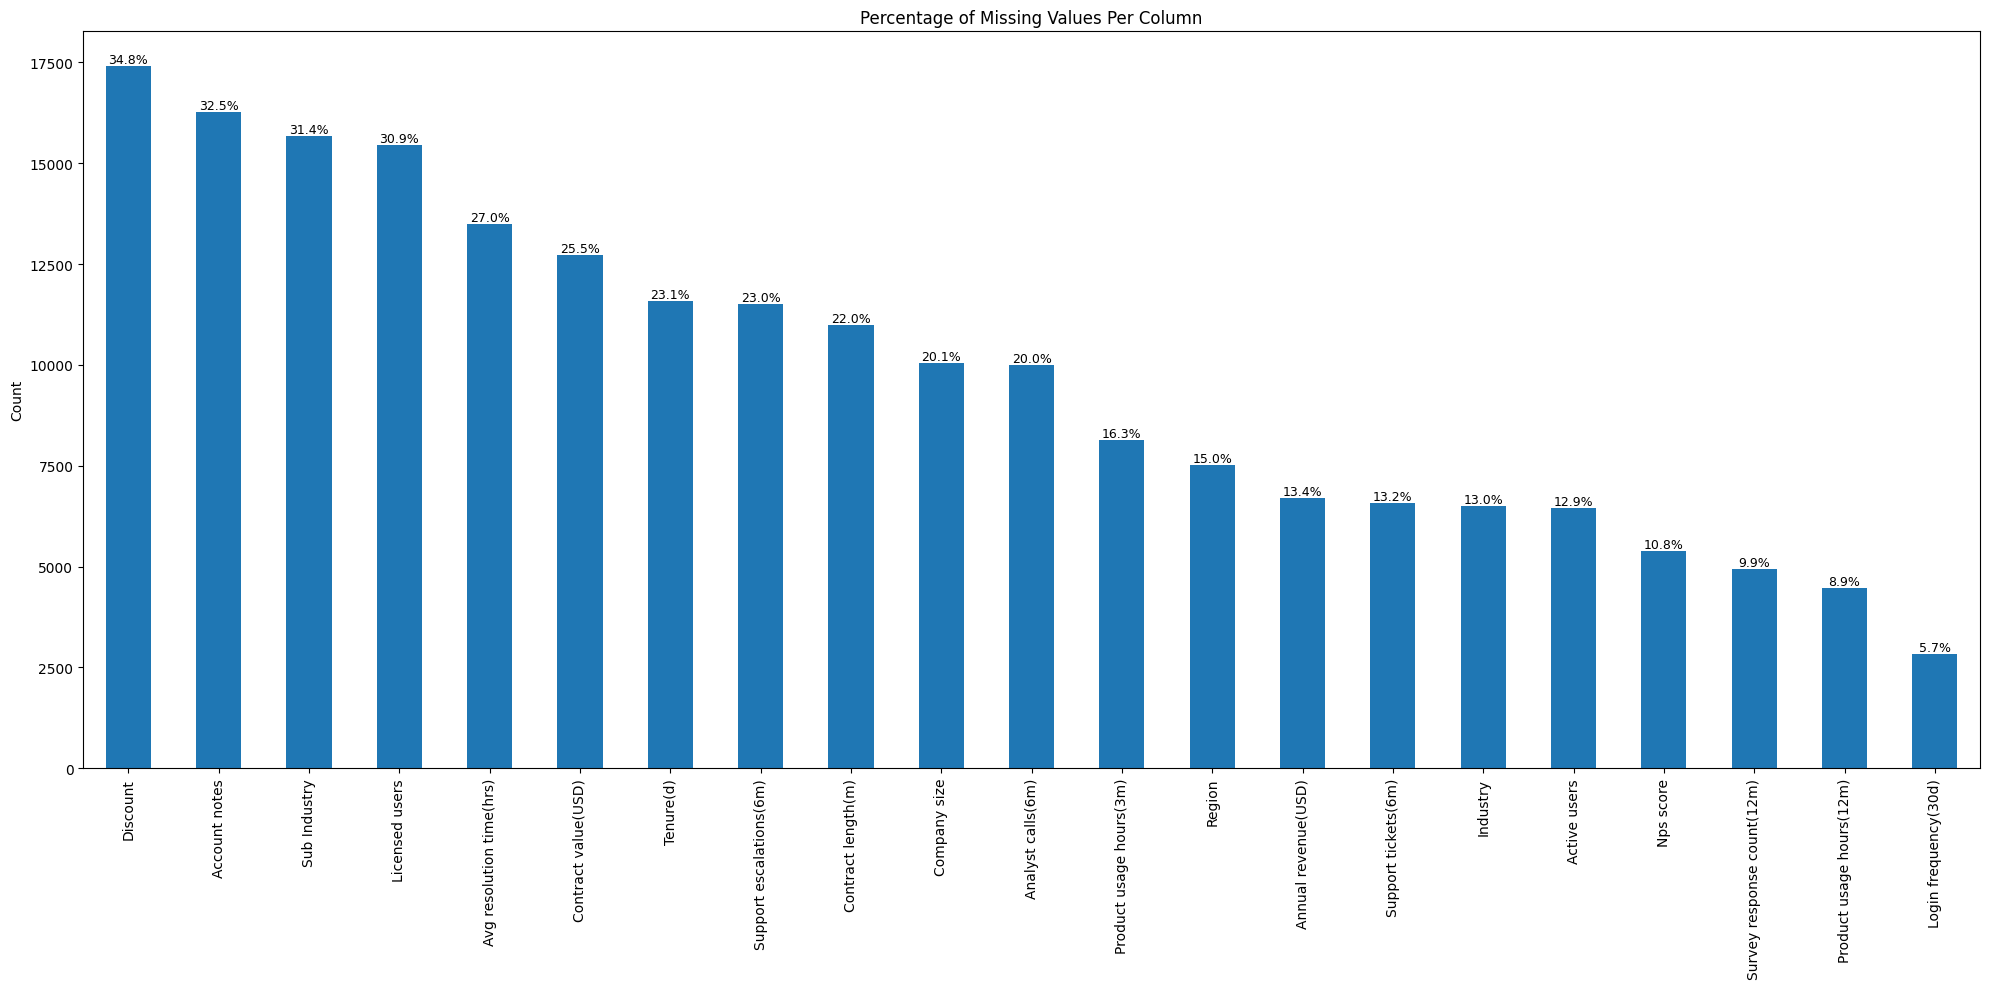

In [44]:
na_counts=df.isna().sum()
na_counts=na_counts[na_counts>0].sort_values(ascending=False)
na_props=na_counts/len(df)

ax=na_counts.plot.bar(figsize=(20,10),title="Percentage of Missing Values Per Column")
ax.set_ylabel("Count")
ax.grid(False)

for patch,prop in zip(ax.patches,na_props):
    ax.annotate(f"{prop:.1%}",
                (patch.get_x()+patch.get_width() / 2, patch.get_height()),
                ha="center",va="bottom",fontsize=9)
plt.tight_layout()
plt.show()

####
* From columns analyst calls to discount, the range of missing values varies between 20% to 35%. Below these columns, we can see a decline in percentage of missing values

<Axes: >

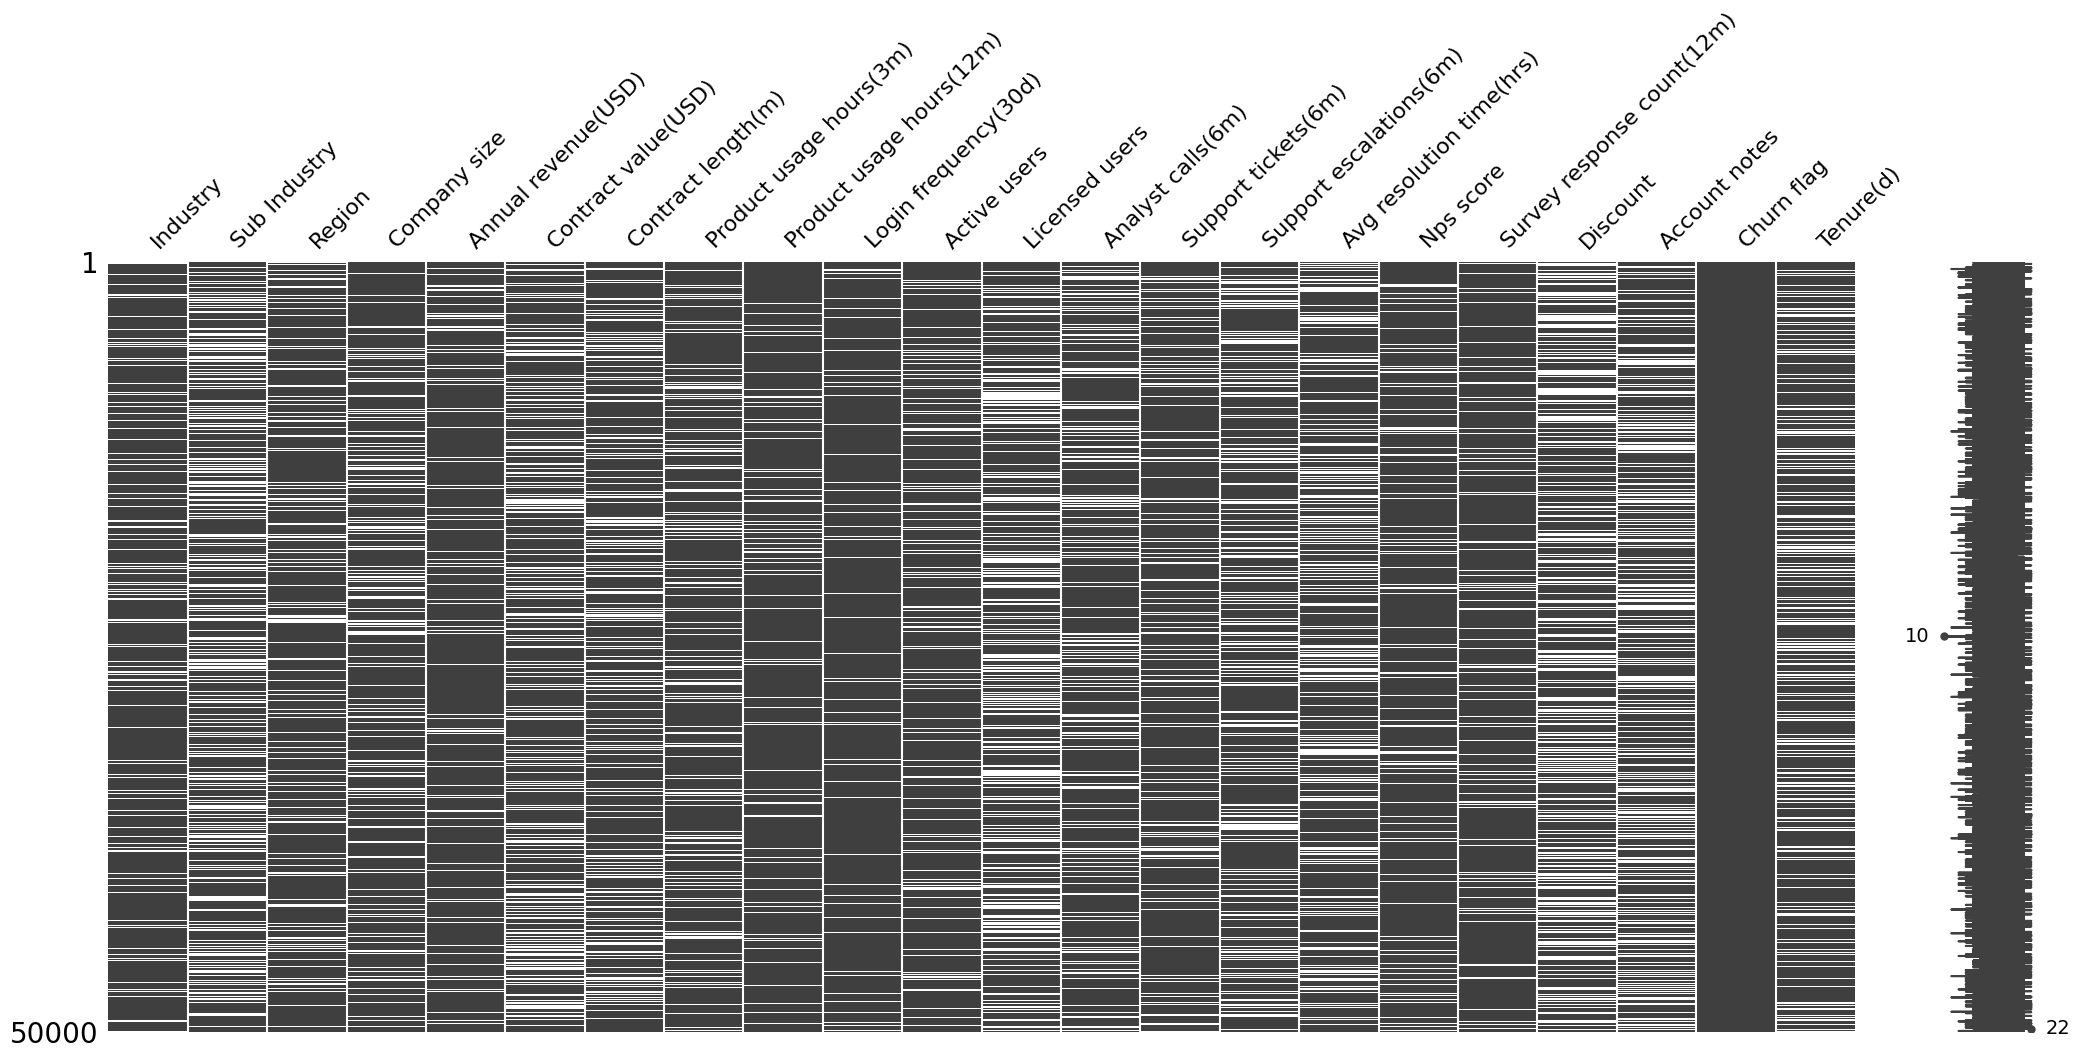

In [22]:
mno.matrix(df)

### 
* White lines represent missing values in each feature and black lines represent non-missing data. We can observe that missing values are more spread out with discount, analyst calls, licensed users and sub-industry having larger data missing

<Axes: >

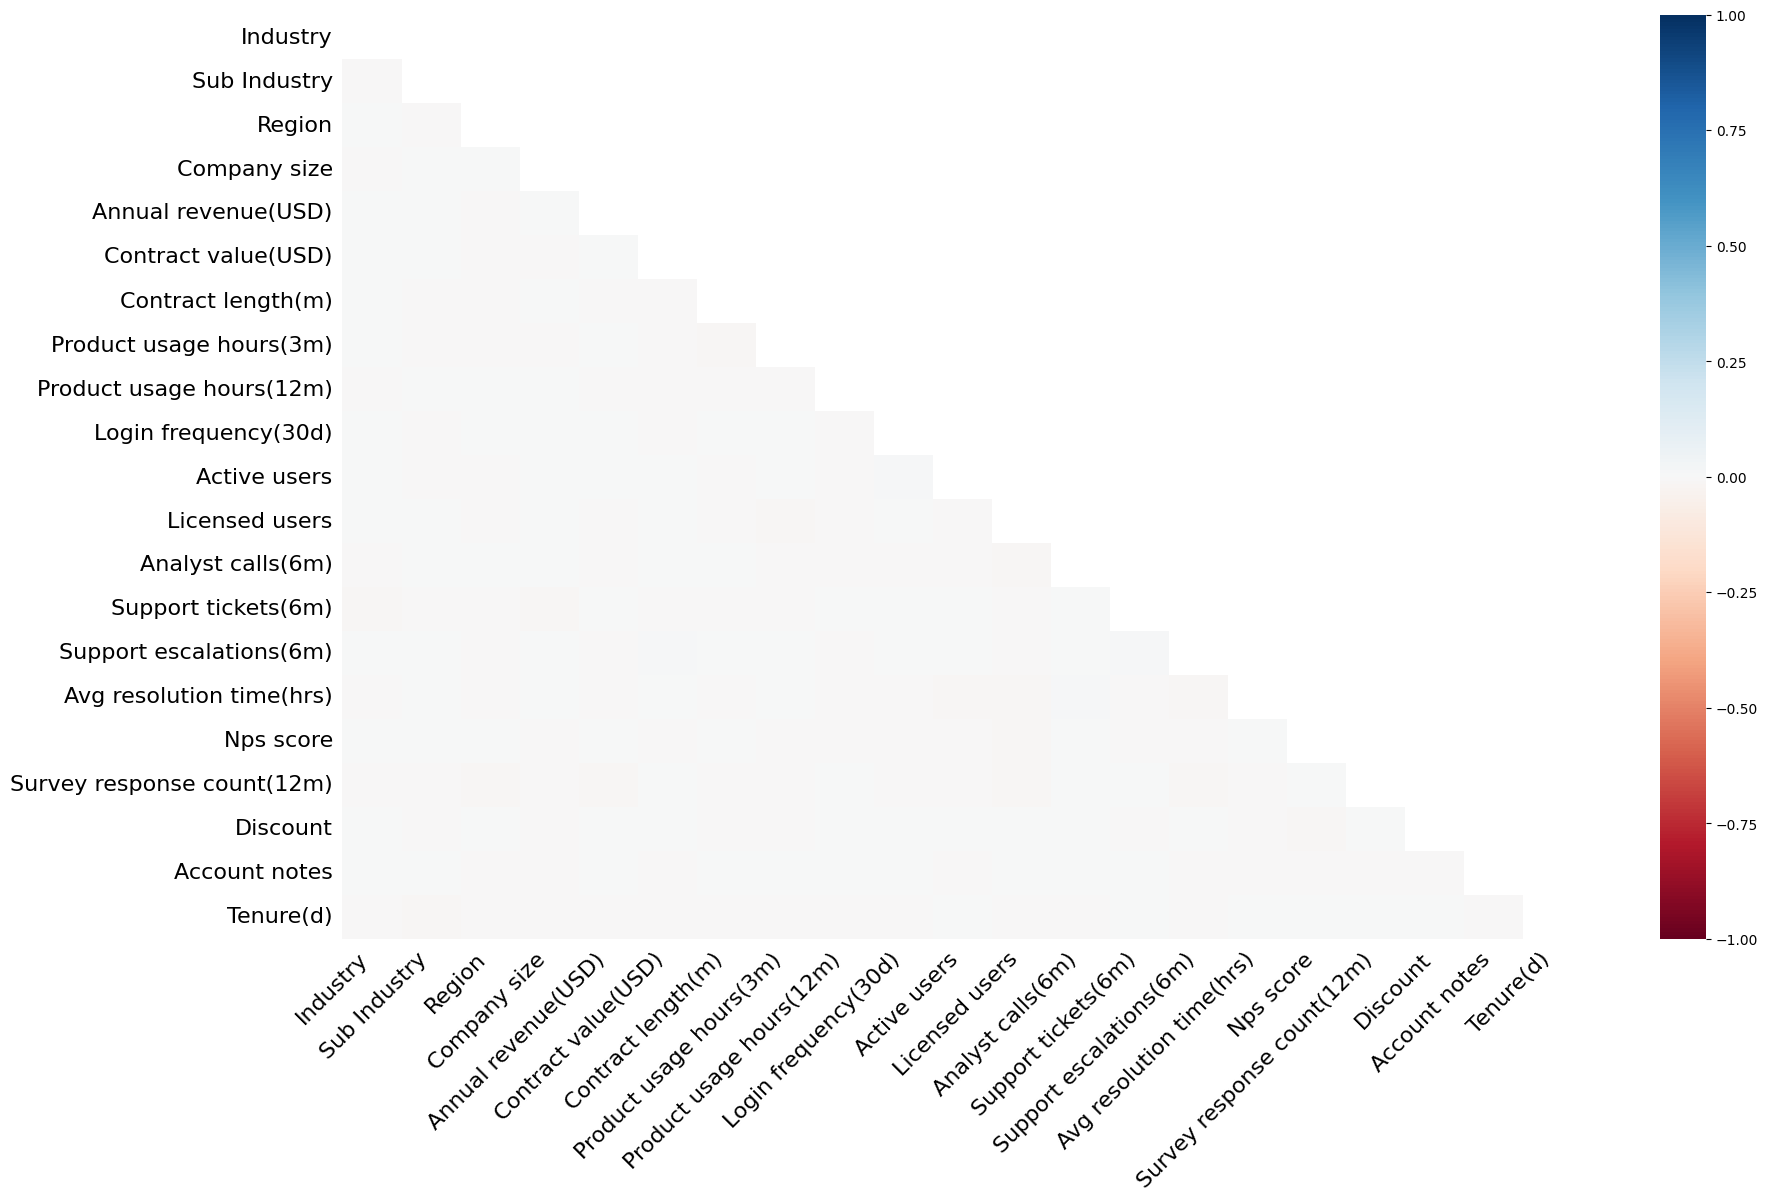

In [23]:
mno.heatmap(df)

* The heatmap is used to see if there is any correlation between missing values of two features. This helps to see if missing values in one feature affect missing values in another. From the above heatmap, we can see that there is no correlation between missing values of different features i.e. the missing data is independent across features

### Missing Data in all numerical features and their relationship with churn

In [24]:
df['missing_discount']=np.where(df['Discount'].isnull(),1,0)
pd.DataFrame(df.groupby('Churn flag')['missing_discount'].mean())

,missing_discount
Churn flag,
0,0.347587
1,0.370672


###
* Clients who did not churn 35% of discount values are missing whereas those who churn 37% of discount values are missing. Since the difference/variation is not much, missing values in discount are not related to churn

In [25]:
df['missing_licensed_users']=np.where(df['Licensed users'].isnull(),1,0)
pd.DataFrame(df.groupby('Churn flag')['missing_licensed_users'].mean())

,missing_licensed_users
Churn flag,
0,0.308642
1,0.325866


###
* Clients who did not churn 30% of licensed users values are missing whereas those who churn 32% of licensed users values are missing. Since the difference/variation is not much, missing values in licensed users is not related to churn

In [26]:
df['missing_avg_resolution']=np.where(df['Avg resolution time(hrs)'].isnull(),1,0)
pd.DataFrame(df.groupby('Churn flag')['missing_avg_resolution'].mean())

,missing_avg_resolution
Churn flag,
0,0.269595
1,0.292261


In [27]:
df['missing_contract']=np.where(df['Contract value(USD)'].isnull(),1,0)
pd.DataFrame(df.groupby('Churn flag')['missing_contract'].mean())

,missing_contract
Churn flag,
0,0.254702
1,0.254582


In [28]:
df['missing_tenure']=np.where(df['Tenure(d)'].isnull(),1,0)
pd.DataFrame(df.groupby('Churn flag')['missing_tenure'].mean())

,missing_tenure
Churn flag,
0,0.231976
1,0.206721


###
* There is no significant difference between missing values of clients who churn v/s those who did not churn in contract value, avg resolution time and tenure hence these are not related to churn

In [29]:
df['missing_support_esc']=np.where(df['Support escalations(6m)'].isnull(),1,0)
pd.DataFrame(df.groupby('Churn flag')['missing_support_esc'].mean())

,missing_support_esc
Churn flag,
0,0.231364
1,0.177189


###
* We can see that for clients who did not churn 23% of the support escalations(6m) values are missing and those who churn 17% of the support escalations(6m) values are missing. This means clients who faced no issues have not raised any escalation therefore this signals "no issue" and not missing data(escalation is not logged since there is no issue). Clients who churn might have some serious issues therefore they must have raised escalations that are logged so their escalation data is less missing 

In [30]:
df['missing_analyst_calls']=np.where(df['Analyst calls(6m)'].isnull(),1,0)
pd.DataFrame(df.groupby('Churn flag')['missing_analyst_calls'].mean())

,missing_analyst_calls
Churn flag,
0,0.195989
1,0.392057


###
* We can see that for clients who did not churn 19.5% of the analyst calls(6m) values are missing and those who churn 39% of the analyst calls(6m) values are missing. This significant difference suggests that missing analyst calls data is related to churn which is an unobserved variable therefore this is MNAR, missingness is linked to target variable

In [31]:
df['missing_product_usage(3m)']=np.where(df['Product usage hours(3m)'].isnull(),1,0)
pd.DataFrame(df.groupby('Churn flag')['missing_product_usage(3m)'].mean())

,missing_product_usage(3m)
Churn flag,
0,0.165796
1,0.003055


###
* We can see that for clients who did not churn 16.5% of the product usage(3m) values are missing and those who churn 0.3% of the product usage(3m) values are missing. This significant difference suggests that missing product usage(3m) data is related to churn which is an unobserved variable therefore this is MNAR, missingness is linked to target variable

In [122]:
df['missing_product_usage(12m)']=np.where(df['Product usage hours(12m)'].isnull(),1,0)
pd.DataFrame(df.groupby('Churn flag')['missing_product_usage(12m)'].mean())

,missing_product_usage(12m)
Churn flag,
0,0.089314
1,0.098778


In [47]:
df['missing_nps_score']=np.where(df['Nps score'].isnull(),1,0)
pd.DataFrame(df.groupby('Churn flag')['missing_nps_score'].mean())

,missing_nps_score
Churn flag,
0,0.109368
1,0.032587


### 
* NPS data is missing more in retained clients as compared to churned clients. This might be interpreted as clients who are unhappy has provided feedback (even negative) relatively more than satisfied clients. Here missing nps score does not depend upon high churn rather likely on survey behaviour

In [105]:
df['missing_contract_length']=np.where(df['Contract length(m)'].isnull(),1,0)
pd.DataFrame(df.groupby('Churn flag')['missing_contract_length'].mean())

,missing_contract_length
Churn flag,
0,0.219980
1,0.213849


####
Testing whether Region/Industry has any impact on missingness in analyst calls

In [32]:
total_region_counts = (
               df['Region'].value_counts()
                           .reset_index()
                           .rename(columns={'count': 'Total_Count'})
                           .set_index('Region')
                )

total_industry_counts = (
               df['Industry'].value_counts()
                           .reset_index()
                           .rename(columns={'count': 'Total_Industry_Count'})
                           .set_index('Industry')
                )

In [33]:
total_region_counts['Percentage_Region(%)'] = (
    (total_region_counts['Total_Count'] / len(df) * 100).round(1)
)
# Count of missing Age values by Embarked location
missing_region_analyst_calls_counts = (
    pd.DataFrame(df.groupby('Region')['missing_analyst_calls'].sum())
    .rename(columns={'missing_analyst_calls': 'Missing_Analyst_calls'})
)
# Combine the total counts and missing Age counts
combined_region_df = pd.concat([total_region_counts, missing_region_analyst_calls_counts], axis=1)
# # Calculate the percentage of missing Age values for each Embarked location
combined_region_df['Percent_Missing_Analyst_calls (%)'] = (
    (combined_region_df['Missing_Analyst_calls'] / combined_region_df['Total_Count'] * 100).round(1)
)
combined_region_df

,Total_Count,Percentage_Region(%),Missing_Analyst_calls,Percent_Missing_Analyst_calls (%)
Region,,,,
Europe,12168,24.3,2451,20.1
North America,12123,24.2,2417,19.9
Apac,6108,12.2,1174,19.2
Middle East,6064,12.1,1241,20.5
Latam,6018,12.0,1188,19.7


In [34]:
total_industry_counts['Percentage_Industry(%)'] = (
    (total_industry_counts['Total_Industry_Count'] / len(df) * 100).round(1)
)
# Count of missing Age values by Embarked location
missing_industry_analyst_calls_counts = (
    pd.DataFrame(df.groupby('Industry')['missing_analyst_calls'].sum())
    .rename(columns={'missing_analyst_calls': 'Missing_Analyst_calls'})
)
# Combine the total counts and missing Age counts
combined_industry_df = pd.concat([total_industry_counts, missing_industry_analyst_calls_counts], axis=1)
# # Calculate the percentage of missing Age values for each Embarked location
combined_industry_df ['Percent_Missing_Analyst_calls (%)'] = (
    (combined_industry_df ['Missing_Analyst_calls'] / combined_industry_df ['Total_Industry_Count'] * 100).round(1)
)
combined_industry_df

,Total_Industry_Count,Percentage_Industry(%),Missing_Analyst_calls,Percent_Missing_Analyst_calls (%)
Industry,,,,
Finance,8695,17.4,1779,20.5
Technology,8619,17.2,1696,19.7
Healthcare,8615,17.2,1707,19.8
Saas,4481,9.0,890,19.9
Manufacturing,4409,8.8,872,19.8
Retail,4371,8.7,890,20.4
Energy,4311,8.6,868,20.1


###
* Neither region nor industry has any impact on missingness in analyst calls hence missing values in analyst calls does not depend on region or industry

####
Testing whether Login Frequency has any impact on missing values in analyst calls

In [46]:
from scipy.stats import ttest_ind
missing=df[df['missing_analyst_calls']==1]['Login frequency(30d)']
not_missing=df[df['missing_analyst_calls']==0]['Login frequency(30d)']
ttest_ind(missing,not_missing,nan_policy='omit')

TtestResult(statistic=np.float64(1.0364148080802877), pvalue=np.float64(0.3000139778864678), df=np.float64(47170.0))

#### 
* P-value is more than 0.05 hence there is no significant difference in login frequency between clients with missing analyst calls and those with non-missing analyst calls. In other words, login behaviour do not explain the missingness in analyst calls. Clients with missing analyst calls values do not differ in login activity compared to those with recorded analyst calls 

####
Testing whether any observed variable has impact on missing values in support escalations. 
Analyzing missing escalation data for clients who churn

In [ ]:
df_churn=df[df['Churn flag']==1]

In [65]:
df_churn['escalation_missing'] = df_churn['Support escalations(6m)'].isna().astype(int)

In [68]:
df_churn.groupby('escalation_missing')[['Analyst calls(6m)','Product usage hours(12m)','Nps score','Login frequency(30d)']].mean()

,Analyst calls(6m),Product usage hours(12m),Nps score,Login frequency(30d)
escalation_missing,,,,
0,0.991968,547.684559,-43.989757,10.052510
1,0.737374,566.898365,-46.136095,9.309313


In [72]:
total_industry_counts = (
               df_churn['Industry'].value_counts()
                           .reset_index()
                           .rename(columns={'count': 'Total_Industry_Count'})
                           .set_index('Industry')
                )

total_region_counts = (
               df_churn['Region'].value_counts()
                           .reset_index()
                           .rename(columns={'count': 'Total_Count'})
                           .set_index('Region')
                )

In [ ]:
total_industry_counts['Percentage_Industry(%)'] = (
    (total_industry_counts['Total_Industry_Count'] / len(df_churn) * 100).round(1)
)
# Count of missing Age values by Embarked location
missing_industry_escalation = (
    pd.DataFrame(df_churn.groupby('Industry')['escalation_missing'].sum())
    .rename(columns={'escalation_missing': 'Missing_Escalation'})
)
# Combine the total counts and missing Age counts
combined_industry_df = pd.concat([total_industry_counts, missing_industry_escalation ], axis=1)
# # Calculate the percentage of missing Age values for each Embarked location
combined_industry_df ['Percent_Missing_Escalation (%)'] = (
    (combined_industry_df ['Missing_Escalation'] / combined_industry_df ['Total_Industry_Count'] * 100).round(1)
)
combined_industry_df

,Total_Industry_Count,Percentage_Industry(%),Missing_Escalation,Percent_Missing_Escalation (%)
Industry,,,,
Technology,181,18.4,38,21.0
Healthcare,162,16.5,20,12.3
Finance,154,15.7,22,14.3
Saas,103,10.5,17,16.5
Retail,99,10.1,24,24.2
Energy,85,8.7,18,21.2
Manufacturing,74,7.5,13,17.6


In [73]:
total_region_counts['Percentage_Region(%)'] = (
    (total_region_counts['Total_Count'] / len(df_churn) * 100).round(1)
)
# Count of missing Age values by Embarked location
missing_region_escalation = (
    pd.DataFrame(df_churn.groupby('Region')['escalation_missing'].sum())
    .rename(columns={'escalation_missing': 'Missing_Escalation'})
)
# Combine the total counts and missing Age counts
combined_region_df = pd.concat([total_region_counts, missing_region_escalation], axis=1)
# # Calculate the percentage of missing Age values for each Embarked location
combined_region_df['Percent_Missing_Escalation (%)'] = (
    (combined_region_df['Missing_Escalation'] / combined_region_df['Total_Count'] * 100).round(1)
)
combined_region_df

,Total_Count,Percentage_Region(%),Missing_Escalation,Percent_Missing_Escalation (%)
Region,,,,
Europe,238,24.2,46,19.3
North America,234,23.8,46,19.7
Middle East,133,13.5,21,15.8
Latam,117,11.9,17,14.5
Apac,104,10.6,22,21.2


###
* Based on this analysis we can see that missing escalation data for churned clients depends upon mulitple observed variables in the data. This segment has low analyst calls, low nps score with moderate product usage. Technology, Retail and Energy experience higher missing escalation data for this segment and APAC also has high missing escalation. This suggests that some clients might not raise issues/complains before leaving but they silently churn or disengage because of low perceived value, are dissatified. The absence of escalation data suggests that churn is not driven by service issues but by a lack of perceived value and silent disengagement. 

* Conclusion: This is the case of MAR. In feature engineering, we can impute missing values of this feature with 0

#### 
Analyzing missing values in Discount

In [79]:
df.groupby(df['Discount'].isna())[[
    "Login frequency(30d)",
    "Analyst calls(6m)",
    "Active users",
    "Nps score"

]].mean()

,Login frequency(30d),Analyst calls(6m),Active users,Nps score
Discount,,,,
False,9.945524,1.509134,6.012574,-0.638849
True,10.018400,1.508239,5.950076,-0.358595


####
* We can see that missing values in discount shows no strong relationship with any of the above observed variables therefore this is not MAR. Since it already includes 0 therefore we cannot say that missing discount = no discount, this might be a system related issue and not business behaviour. Check distribution while imputing

In [83]:
df.groupby(df['Licensed users'].isna())[[
    "Login frequency(30d)",
    "Analyst calls(6m)",
    "Active users",
    "Nps score"

]].mean()

,Login frequency(30d),Analyst calls(6m),Active users,Nps score
Licensed users,,,,
False,9.958632,1.50613,5.981396,-0.483222
True,9.998189,1.514793,6.011862,-0.66842


In [84]:
df.groupby('Region')['Licensed users'].apply(lambda x:x.isna().mean())

Region
Apac             0.311231
Europe           0.310240
Latam            0.309073
Middle East      0.312830
North America    0.306195
Name: Licensed users, dtype: float64

In [85]:
df.groupby('Industry')['Licensed users'].apply(lambda x:x.isna().mean())

Industry
Energy           0.308281
Finance          0.310408
Healthcare       0.302728
Manufacturing    0.313450
Retail           0.310913
Saas             0.298594
Technology       0.314654
Name: Licensed users, dtype: float64

###
* Missing values in licensed users is a case of MCAR

In [123]:
missing_cols=[
    "missing_avg_resolution",
    "missing_tenure",
    "missing_contract",
    "missing_contract_length",
    "missing_nps_score",
    "missing_product_usage(3m)"
]

missing_summary=(df.
                 groupby(['Industry'])[missing_cols]
                 .mean()
                 .reset_index()
)
missing_summary = missing_summary.rename(columns={
    'missing_avg_resolution': 'avg_resolution_pct_missing',
    'missing_tenure': 'tenure_pct_missing',
    'missing_contract': 'contract_pct_missing',
    'missing_contract_length':'contract_length_pct_missing',
    "missing_nps_score":"missing_nps_score_pct_missing",
    "missing_product_usage(3m)":"missing_product_usage(3m)_pct_missing"
})
missing_summary

,Industry,avg_resolution_pct_missing,tenure_pct_missing,contract_pct_missing,contract_length_pct_missing,missing_nps_score_pct_missing,missing_product_usage(3m)_pct_missing
0,Energy,0.276502,0.233125,0.242867,0.218511,0.111575,0.159128
1,Finance,0.270270,0.235308,0.253019,0.221967,0.110638,0.164692
2,Healthcare,0.264771,0.226349,0.258967,0.216483,0.102960,0.157284
3,Manufacturing,0.284418,0.233386,0.240871,0.214561,0.103652,0.160581
4,Retail,0.272020,0.245482,0.269504,0.220544,0.096774,0.161062
5,Saas,0.266235,0.228297,0.247936,0.223611,0.110243,0.162910
6,Technology,0.268593,0.230653,0.258267,0.218703,0.111614,0.166841


In [124]:
missing_summary=(df.
                 groupby(['Region'])[missing_cols]
                 .mean()
                 .reset_index()
)
missing_summary = missing_summary.rename(columns={
    'missing_avg_resolution': 'avg_resolution_pct_missing',
    'missing_tenure': 'tenure_pct_missing',
    'missing_contract': 'contract_pct_missing',
    'missing_contract_length':'contract_length_pct_missing',
    "missing_nps_score":"missing_nps_score_pct_missing",
    "missing_product_usage(3m)":"missing_product_usage(3m)_pct_missing"
})
missing_summary

,Region,avg_resolution_pct_missing,tenure_pct_missing,contract_pct_missing,contract_length_pct_missing,missing_nps_score_pct_missing,missing_product_usage(3m)_pct_missing
0,Apac,0.280616,0.238540,0.252128,0.220530,0.116732,0.157007
1,Europe,0.267669,0.234550,0.256082,0.222880,0.101331,0.169954
2,Latam,0.270189,0.230309,0.256065,0.220339,0.117149,0.162512
3,Middle East,0.267480,0.222790,0.258410,0.218338,0.106860,0.166062
4,North America,0.270313,0.230966,0.255300,0.219088,0.105254,0.159202


In [ ]:
df.groupby(df['Avg resolution time(hrs)'].isna())[[
    "Login frequency(30d)",
    "Analyst calls(6m)",
    "Active users",
    "Nps score"

]].mean()

,Login frequency(30d),Analyst calls(6m),Active users,Nps score
Avg resolution time(hrs),,,,
False,10.011944,1.498891,5.990761,-0.640554
True,9.859898,1.536058,5.991033,-0.271278


###
* Missingness in avg resolution time is a case of MAR since missing resolution time suggests no tickets are raised therefore this means that clients have no queries or issues and thereby NPS is higher as compared to non-missing data

In [103]:
df.groupby(df['Contract value(USD)'].isna())[[
    "Login frequency(30d)",
    "Analyst calls(6m)",
    "Active users",
    "Nps score"
]].mean()

,Login frequency(30d),Analyst calls(6m),Active users,Nps score
Contract value(USD),,,,
False,9.958195,1.511736,5.986422,-0.133179
True,10.007855,1.500295,6.003799,-1.731043


In [120]:
df.groupby(df['Tenure(d)'].isna())[[
    "Login frequency(30d)",
    "Analyst calls(6m)",
    "Active users",
    "Nps score",
    "Support tickets(6m)",
    "Support escalations(6m)",
    'Avg resolution time(hrs)',
    'Survey response count(12m)',
    'Product usage hours(12m)'
]].mean()

,Login frequency(30d),Analyst calls(6m),Active users,Nps score,Support tickets(6m),Support escalations(6m),Avg resolution time(hrs),Survey response count(12m),Product usage hours(12m)
Tenure(d),,,,,,,,,
False,9.961015,1.507477,5.992171,-0.691886,3.517835,0.599099,49.199716,1.196461,519.712155
True,10.003478,1.513261,5.986398,-0.036666,3.4993,0.596947,49.589611,1.16812,521.873559


###
* Hypothesis: Missing tenure data means new clients
* Tenure is not MNAR because missigness is not related to tenure itself(tenure itself influence whether it is missing). Missing tenure data means clients are not new since product usage is high(Not MAR) and this could be a system issue and hence this is a case of MCAR

In [109]:
df.groupby(df['Contract length(m)'].isna())[[
    "Login frequency(30d)",
    "Analyst calls(6m)",
    "Active users",
    "Nps score"
]].mean()

,Login frequency(30d),Analyst calls(6m),Active users,Nps score
Contract length(m),,,,
False,9.979285,1.51238,5.990694,-0.514722
True,9.940870,1.496188,5.991335,-0.633728


### 
* Missing contract length data has lower nps as compared to non-missing contract length. This could be due to poor management of contracts or bad experience of clients. This is a case of MAR

In [121]:
df.groupby(df['Nps score'].isna())[[
    "Login frequency(30d)",
    "Analyst calls(6m)",
    "Active users",
    'Survey response count(12m)'
]].mean()

,Login frequency(30d),Analyst calls(6m),Active users,Survey response count(12m)
Nps score,,,,
False,9.979343,1.512222,5.991967,1.189207
True,9.900646,1.480559,5.981474,1.195639


###
* Missing NPS values were more likely due to survey participation behavior rather than dissatisfaction or disengagement. Therefore, treated it as approximately MCAR and will use median imputation to handle it

In [125]:
df.groupby(df['Product usage hours(3m)'].isna())[[
    "Login frequency(30d)",
    "Analyst calls(6m)",
    "Active users",
    'Nps score',
    "Support tickets(6m)"
]].mean()

,Login frequency(30d),Analyst calls(6m),Active users,Nps score,Support tickets(6m)
Product usage hours(3m),,,,,
False,9.947910,1.506153,5.99863,-0.493501,3.515388
True,10.089001,1.522518,5.950489,-0.783109,3.504229


### 
* Clients with missing product usage data had similar or higher engagement levels, indicating that they were actively using the product. This suggested that missingness was due to data tracking issues rather than inactivity. Interestingly, these clients had slightly lower NPS scores, indicating a potential gap between usage and perceived value. We can impute this with product usage(12m) values